In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cs-training.csv', index_col=0)
        # should print (150000, 11)

# print(df.info())
# print(df.describe())

In [3]:
df.head()

# What each column means:

# SeriousDlqin2yrs → Target: 1 = defaulted, 0 = did not default
# RevolvingUtilizationOfUnsecuredLines → Credit card usage ratio
# age → Borrower age
# NumberOfTime30-59DaysPastDueNotWorse → Late payments (30–59 days)
# DebtRatio → Monthly debt / monthly income
# MonthlyIncome → Monthly income in dollars
# NumberOfOpenCreditLinesAndLoans → Total open loans
# NumberOfTimes90DaysLate → Severely late payments
# NumberRealEstateLoansOrLines → Mortgage / home loans
# NumberOfTime60-89DaysPastDueNotWorse → Moderately late payments
# NumberOfDependents → Number of dependents

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df.shape

(150000, 11)

In [5]:
# check missing values
missing = df.isnull().sum()
print(missing[missing > 0])

MonthlyIncome         29731
NumberOfDependents     3924
dtype: int64


In [6]:
# Fill missing values
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

# Use mean when data has no outliers (normal distribution)
# Use median when data has outliers or skewed values
# Use mode for categorical (most frequent value)

In [7]:
# Check class imbalance (how many defaults vs non-defaults)
print(df['SeriousDlqin2yrs'].value_counts())
# Expected: ~93% non-default, ~7% default — this is imbalanced!

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


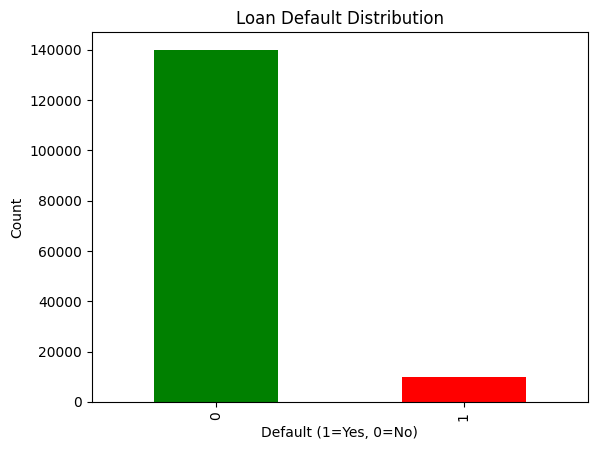

In [8]:
# Plot target distribution
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Loan Default Distribution')
plt.xlabel('Default (1=Yes, 0=No)')
plt.ylabel('Count')
plt.show()

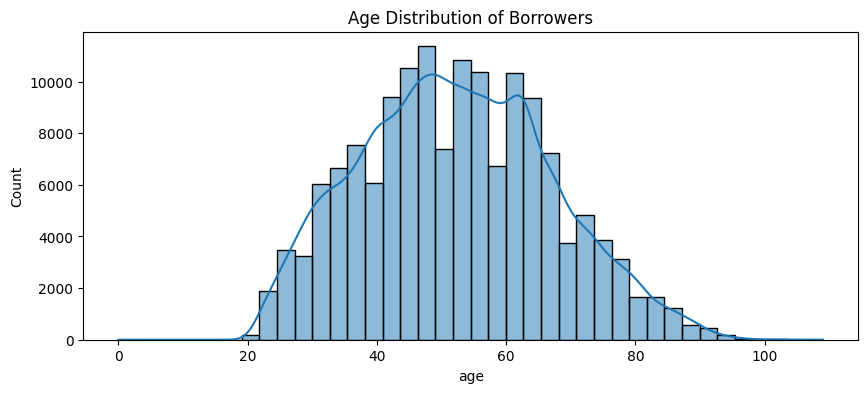

In [9]:
# Age distribution
plt.figure(figsize=(10,4))
sns.histplot(df['age'], bins=40, kde=True)
plt.title('Age Distribution of Borrowers')
plt.show()

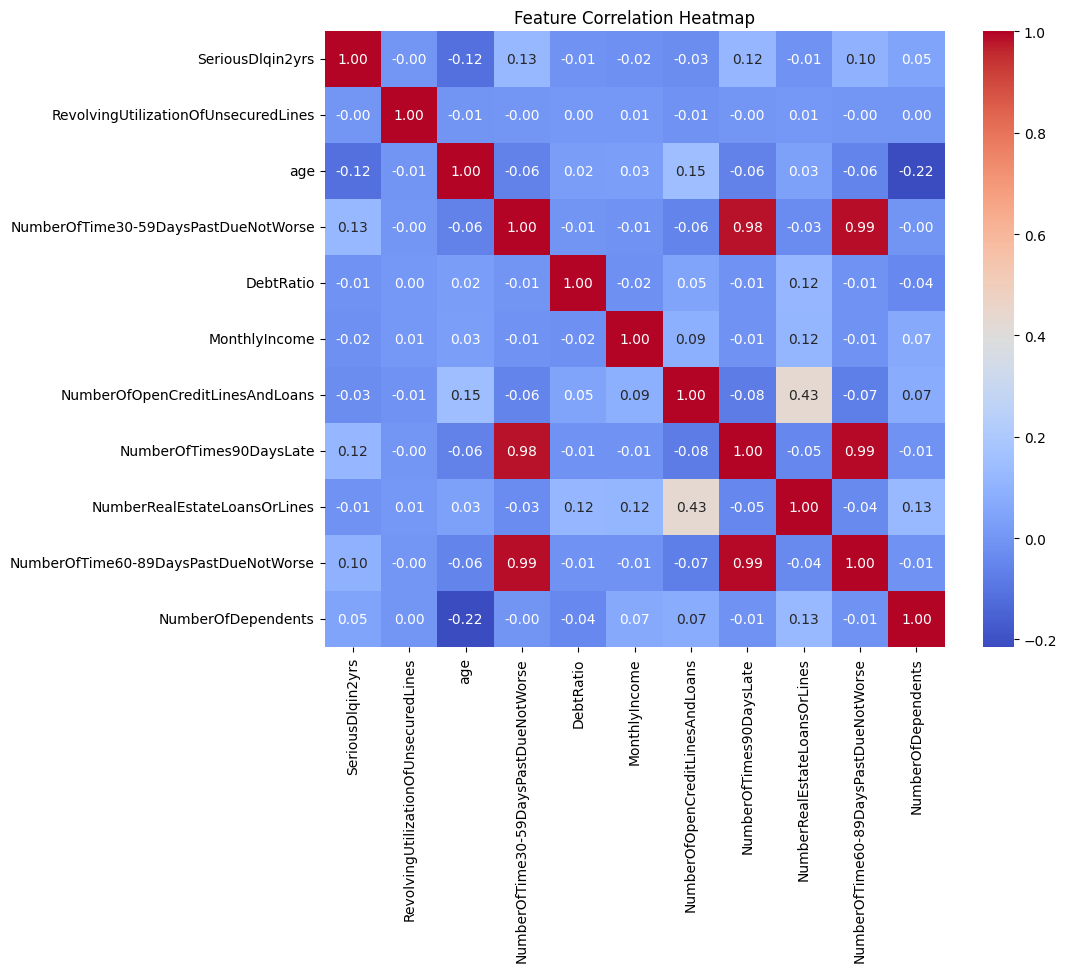

In [10]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [11]:
# Look at the statistics of each column
print(df.describe())

# You will see scary numbers like:
# DebtRatio max = 329,664    ← impossible, should be 0-5
# MonthlyIncome max = 3,008,750  ← extreme outlier
# RevolvingUtilization max = 50,708  ← impossible, should be 0-1

# These outliers are destroying your correlation values
# and will confuse your model — fix them in Phase 3

       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines            age  \
count     150000.000000                         150000.000000  150000.000000   
mean           0.066840                              6.048438      52.295207   
std            0.249746                            249.755371      14.771866   
min            0.000000                              0.000000       0.000000   
25%            0.000000                              0.029867      41.000000   
50%            0.000000                              0.154181      52.000000   
75%            0.000000                              0.559046      63.000000   
max            1.000000                          50708.000000     109.000000   

       NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  MonthlyIncome  \
count                         150000.000000  150000.000000   1.500000e+05   
mean                               0.421033     353.005076   6.418455e+03   
std                                4.192781    2